In [5]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import numpy as np

from torch.utils.data import TensorDataset, DataLoader
from torch.nn.utils import parameters_to_vector, vector_to_parameters
from tqdm import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt

from sv3.nn import SvenWrapper, MLP
from sv3.sven import Sven

import sys
sys.path.append('..')
import copy
from pathlib import Path
import pandas as pd
import pickle

from experiments.experiment_code.experiment_utils import train_loop_standard, train_loop_svd, set_seed

device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print(f"Using device: {device}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using device: mps


In [6]:
LOADER_SEED = 51159
MODEL_SEED = 4372892
DATA_SEED = 54631
batch_size = 32
K = 16
lr_svd = 0.1
n_epoch = 20
lr_standard = 1e-3
rtol = 1e-2
drop_last = True
mlp_kwargs = {
    "input_dim": 1,
    "hidden_dims": [16,16,16],
    "output_dim": 1
}
standard_optimizers = ['Adam','SGD','RMSprop']

In [7]:
from torchvision import datasets, transforms
from experiments.datasets import Toy1DRegressionDataset

toy_1d = Toy1DRegressionDataset(seed=DATA_SEED)
train_dataset = toy_1d.train_dataset
test_dataset = toy_1d.val_dataset

In [8]:
set_seed(MODEL_SEED)
mlp_base = MLP(**mlp_kwargs)
init_state = copy.deepcopy(mlp_base.state_dict())
del mlp_base # free memory

### Train with LBFGS

In [14]:
lr_lbfgs = 1.0
lbfgs_max_iter = 5
lbfgs_history_size = 100
lbfgs_line_search_fn = 'strong_wolfe'

device = 'cpu'
model_lbfgs = MLP(**mlp_kwargs)
model_lbfgs.load_state_dict(init_state)
model_lbfgs = model_lbfgs.to(device)

# LBFGS needs a scalar loss; wrap per-sample loss with mean
def loss_fn_scalar(pred, y):
    loss = (pred - y) ** 2
    return loss.sum(dim=-1).mean()

optimizer_lbfgs = torch.optim.LBFGS(
    model_lbfgs.parameters(),
    lr=lr_lbfgs,
    max_iter=lbfgs_max_iter,
    history_size=lbfgs_history_size,
    line_search_fn=lbfgs_line_search_fn,
)

train_loader = DataLoader(
    toy_1d.train_dataset, batch_size=batch_size, shuffle=True,
    generator=torch.Generator().manual_seed(LOADER_SEED), drop_last=drop_last,
)
test_loader = DataLoader(toy_1d.val_dataset, batch_size=256, shuffle=False)

model_lbfgs, losses_lbfgs = train_loop_standard(
    model_lbfgs, optimizer_lbfgs, loss_fn_scalar,
    train_loader, test_loader, n_epoch, device,
)

Using device cpu


100%|██████████| 20/20 [00:31<00:00,  1.60s/it]


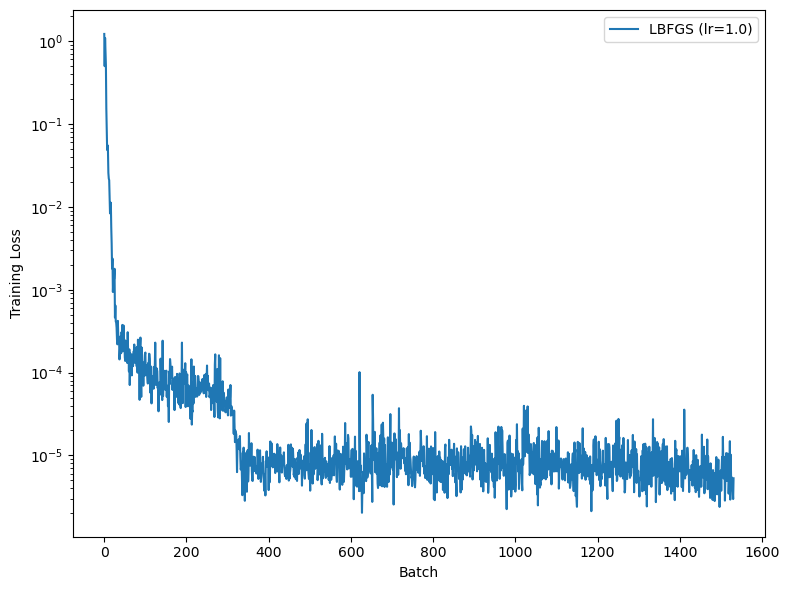

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(losses_lbfgs['train_batch'], label=f'LBFGS (lr={lr_lbfgs})')
ax.set_xlabel('Batch')
ax.set_ylabel('Training Loss')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()

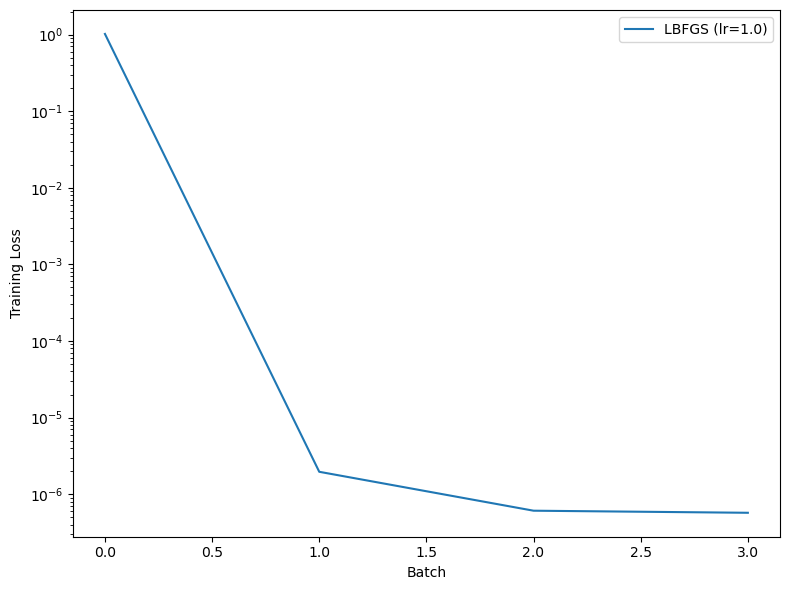

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(losses_lbfgs['val'], label=f'LBFGS (lr={lr_lbfgs})')
ax.set_xlabel('Batch')
ax.set_ylabel('Training Loss')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()